<a href="https://colab.research.google.com/github/Kirieshka124/ml_basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9610_%D0%A0%D0%B0%D0%B7%D0%B2%D0%B5%D0%B4%D0%BE%D1%87%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%2C_%D0%BF%D1%80%D0%B5%D0%B4%D0%BE%D0%B1%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_%D0%B8_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B5%D0%B9_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №10. Разведочный анализ, предобработка данных и обучение моделей классификации**

*(на примере датасета Bank Marketing)*

---

## ****Введение****

**Цель работы:** Обучить модель машинного обучения для предсказания, откроет ли клиент банка срочный вклад по результатам маркетинговой кампании (целевая переменная `y`: "yes" — откроет, "no" — не откроет).

**Датасет:** [Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing) — данные о маркетинговых кампаниях португальского банка.

**Что вы научитесь делать:**
- Загружать и исследовать данные
- Выявлять проблемы через разведочный анализ (EDA)
- Анализировать и обрабатывать пропущенные значения
- Формулировать и **экспериментально проверять** гипотезы
- Создавать новые признаки (Feature Engineering)
- **Сравнивать все изученные методы классификации**
- **Выбирать лучшие модели и оптимизировать их гиперпараметры с помощью GridSearchCV**
- **Анализировать влияние комбинаций признаков на качество модели**

---

## ****Часть 1. Настройка окружения****

> 📚 **Подсказка:** Аналогичная настройка рассматривалась в [**Занятии 1, Часть 1** и **Занятии 2, Часть 1**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=5f49d9aa).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, roc_curve, confusion_matrix,
                            classification_report)

# Модели классификации
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Отбор признаков
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from itertools import combinations

# Настройки отображения
sns.set_style("whitegrid")
pd.set_option('display.max_columns', 20)

---

## ****Часть 2. Загрузка и первичный осмотр данных****

> 📚 **Подсказка:** Методы первичного осмотра (`head()`, `info()`, `describe()`, `shape`) подробно разобраны в [**Занятии 1, Часть 3.2**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=9ef7543b) и [**Занятии 2, Часть 2.1**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=43b439e3).

### ****Задание 2.1. Загрузите датасет****

In [5]:
url = "https://raw.githubusercontent.com/rishabhathiya/Bank-Marketing/refs/heads/main/bank.csv"
bank = pd.read_csv(url, sep=';')

bank = bank.replace('unknown', np.nan)

bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no


### ****Задание 2.2. Изучите структуру данных****

**1. Выведите размерность датасета:**

In [6]:
bank.shape

(4521, 17)

**2. Отобразите первые 10 строк датасета**

In [7]:
bank.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,NaN,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,NaN,14,may,57,2,-1,0,NaN,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


**3. Выведите информацию о типах данных и пропусках**

In [8]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4483 non-null   object
 2   marital    4521 non-null   object
 3   education  4334 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    3197 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   816 non-null    object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


**4. Выведите статистику числовых признаков**

In [9]:
bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


**5. Выведите названия всех столбцов в виде списка строк**

In [10]:
bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

### ****Задание 2.3. Ответьте на вопросы****

---

> 📝 **Как отвечать на текстовые вопросы?** Дважды кликните на ячейку → впишите ответ → нажмите `Shift+Enter`

---

**Вопрос 1:** Сколько записей (клиентов) в датасете?

**Ответ:** 4521

**Вопрос 2:** Сколько признаков (столбцов)?

**Ответ:** 16 (не считая y)

**Вопрос 3:** Какая переменная является целевой (что предсказываем)?

**Ответ:** столбец y

**Вопрос 4:** Какие типы данных преобладают — числовые или категориальные?

**Ответ:** категориальные (7 числовых, 9 категориальных без у)

---

### ****Описание столбцов датасета Bank Marketing****

| Столбец | Описание | Тип |
|---------|----------|-----|
| `age` | Возраст клиента | Числовой |
| `job` | Тип занятости | Категориальный |
| `marital` | Семейное положение | Категориальный |
| `education` | Уровень образования | Категориальный |
| `default` | Есть ли дефолт по кредиту | Категориальный |
| `balance` | Баланс на счёте (евро) | Числовой |
| `housing` | Есть ли ипотека | Категориальный |
| `loan` | Есть ли личный кредит | Категориальный |
| `contact` | Тип связи | Категориальный |
| `day` | День последнего контакта | Числовой |
| `month` | Месяц последнего контакта | Категориальный |
| `duration` | Длительность последнего звонка (сек) | Числовой |
| `campaign` | Кол-во контактов в этой кампании | Числовой |
| `pdays` | Дней с последнего контакта (-1 = не было) | Числовой |
| `previous` | Кол-во контактов до этой кампании | Числовой |
| `poutcome` | Результат прошлой кампании | Категориальный |
| `y` | **Целевая переменная:** открыл ли вклад | Категориальный |

---

## ****Часть 3. Разведочный анализ данных (EDA)****

> 📚 **Подсказка:** Цель EDA — выявить проблемы в данных и найти закономерности (паттерны). Методология описана в [**Занятии 2, Часть 2**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=29f19e7a).

### ****3.1. Анализ целевой переменной (баланс классов)****

> 📚 **Подсказка:** Анализ баланса классов рассмотрен в [**Занятии 2, Часть 2.3**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=15c684d7).

In [11]:
bank['target'] = (bank['y'] == 'yes').astype(int)

bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no,0
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,0
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,0
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no,0
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no,0


**Подсчитайте распределение целевой переменной 'y'**

In [12]:
bank['y'].value_counts()

,count
y,
no,4000
yes,521


**Вопрос:** сколько клиентов открыли депозит (yes)? сколько не открыли (no)?

**Ответ:** yes - 521, no - 4000

---

**Визуализируйте распределения классов графически (постройте столбчатую (barplot) или круговую (pie chart) диаграмму)**

<Axes: xlabel='y'>

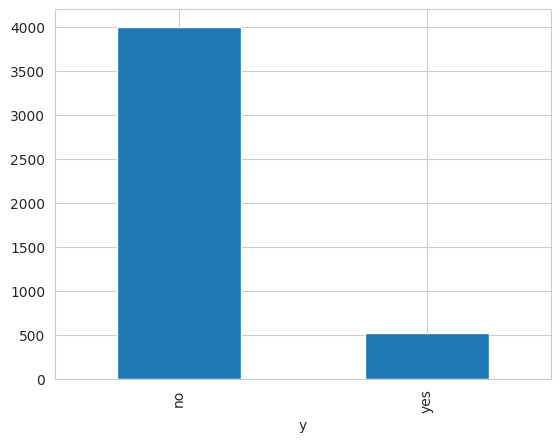

In [13]:
import seaborn as sns

bank['y'].value_counts().plot(kind='bar')

---

**Вычислите процент клиентов, открывших вклад**

In [14]:
(bank['y'].value_counts() / bank['y'].value_counts().sum()) * 100

,count
y,
no,88.476001
yes,11.523999


**Вопрос:** Сбалансированы ли классы? Какой класс преобладает?

**Ответ:** не сбалансированы. Преобладает класс "no"

---

### ****3.2. Анализ пропущенных значений****

> 📚 **Подсказка:** Проверка пропусков с помощью `isna().sum()` показана в [**Занятии 1, Часть 3.6**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=1f244634) и [**Занятии 2, Часть 2.2**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=e96e5f15).

**Проверьте наличие пропущенных значений в датасете с помощью `isna().sum()`**

In [15]:
bank.isna().sum()[bank.isna().sum() > 0]

,0
job,38
education,187
contact,1324
poutcome,3705


**Вычислите процент пропущенных значений в каждом столбце датасета**

In [16]:
(bank.isna().sum()[bank.isna().sum() > 0] / bank.shape[0]) * 100

,0
job,0.840522
education,4.136253
contact,29.285556
poutcome,81.950896


**Постройте столбчатую диаграмму (`barplot`) для визуализации процента пропусков**

<Axes: >

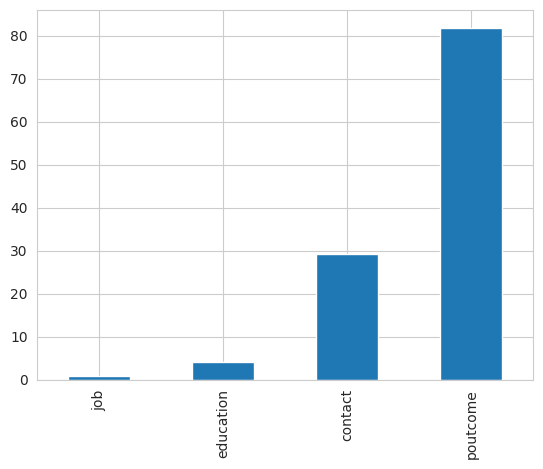

In [17]:
((bank.isna().sum()[bank.isna().sum() > 0] / bank.shape[0])*100).plot(kind='bar')

**Вопрос:** В каких столбцах больше всего пропусков? Какой процент данных потеряем, если удалим все строки с пропусками?

**Ответ:** больше всего в столбце poutcome. Потеряем около 85% данных

---

### ****3.3. Анализ числовых признаков****

> 📚 **Подсказка:** Построение гистограмм с разбивкой по целевой переменной (`hue`) показано в [**Занятии 2, Часть 2.4**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=ea28aa58).

**Обязательно постройте гистограммы для следующих признаков:**
- `age` — возраст
- `balance` — баланс на счёте  
- `duration` — длительность звонка

**Постройте гистограммы для числовых признаков с разбивкой по целевой переменной**

> Используйте `sns.histplot()` с параметром `hue='target'`

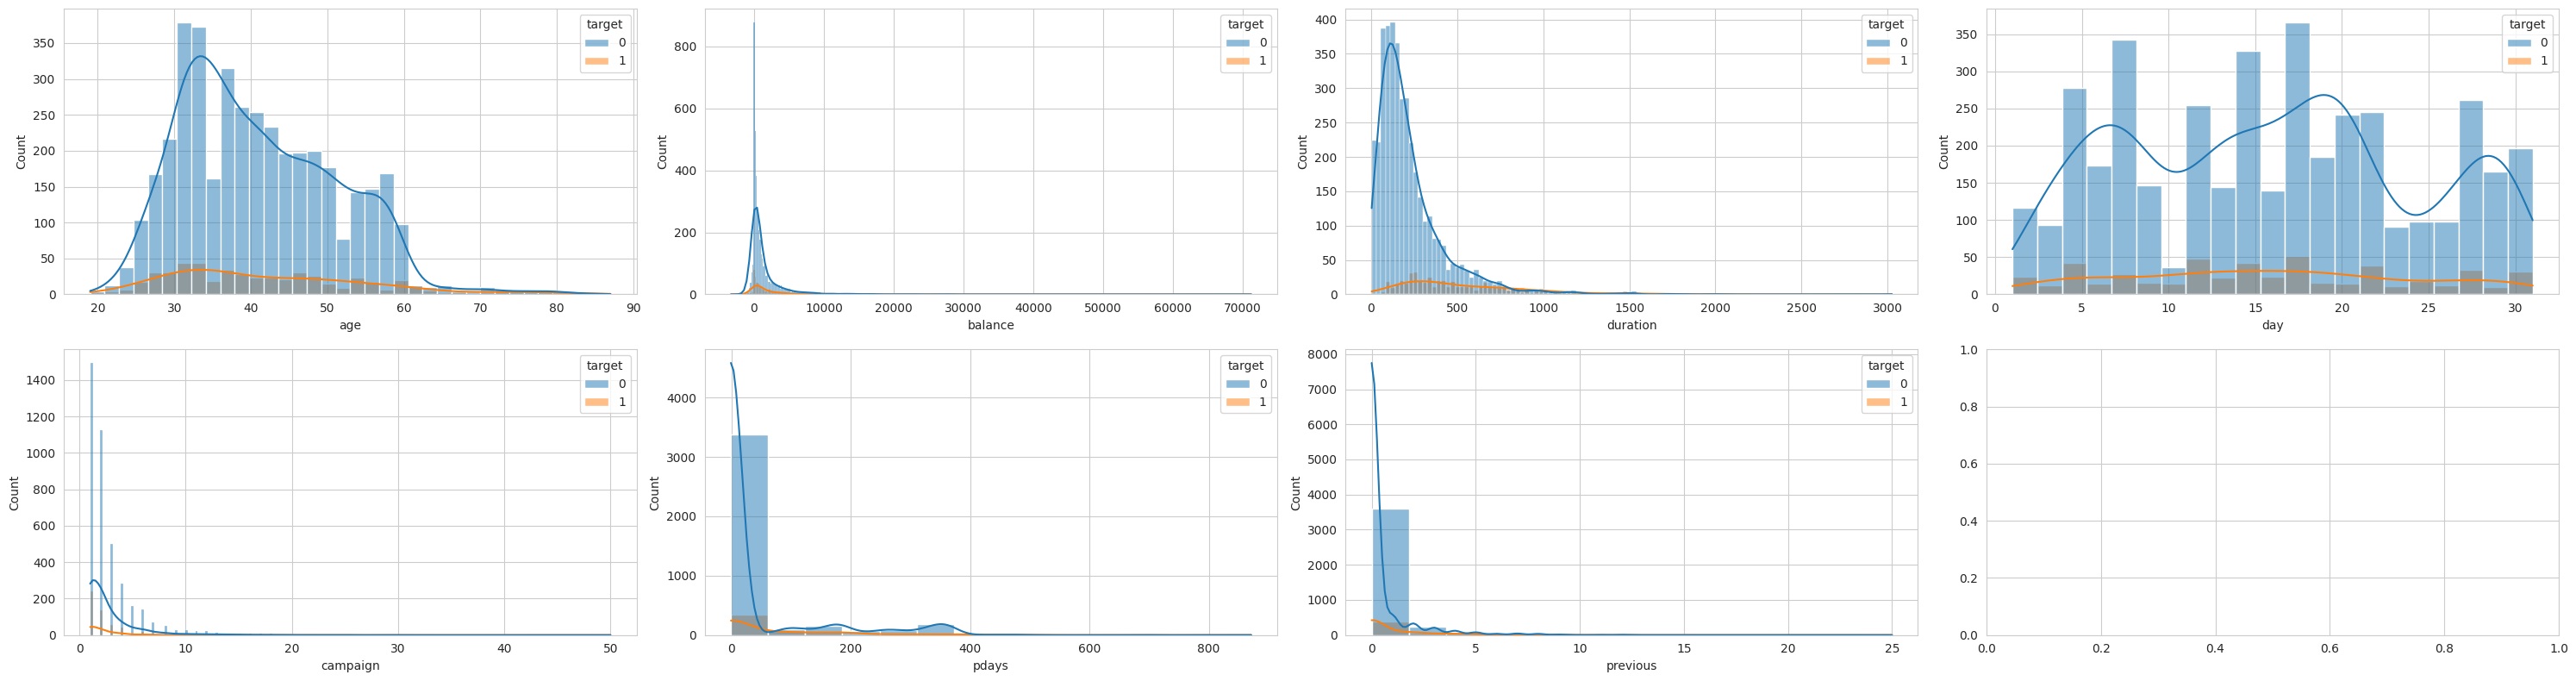

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_features = ['age', 'balance', 'duration', 'day', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(2, 4, figsize=(30, 8))

for i, col in enumerate(numeric_features):
  if i > 3:
    ix = 1
    iy = i-4
  else:
    ix = 0
    iy = i
  sns.histplot(data=bank, x=col, hue='target', kde=True, ax=axes[(ix, iy)])


plt.tight_layout()
plt.show()

*(При желании, можете не использовать мои шаблоны, а написать код для построения графиков с нуля и самостоятельно)*

**Вопрос:** Какие наблюдения вы можете сделать? Какие признаки различаются для клиентов, открывших и не открывших вклад?

**Ответ:** различаются признаки balance, duration и pdays

Остальные признаки относительно одинаковы для всех



---

### ****Задание 3.4. Анализ категориальных признаков****

> 📚 **Подсказка:** Построение столбчатой диаграммы (`barplot`) для анализа связи категориальных признаков с целевой переменной показано в [**Занятии 2, Часть 2.5**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=ea6a781f).

**Постройте графики для анализа доли открывших депозит по категориальным признакам ('job', 'marital', 'education', 'contact'):**

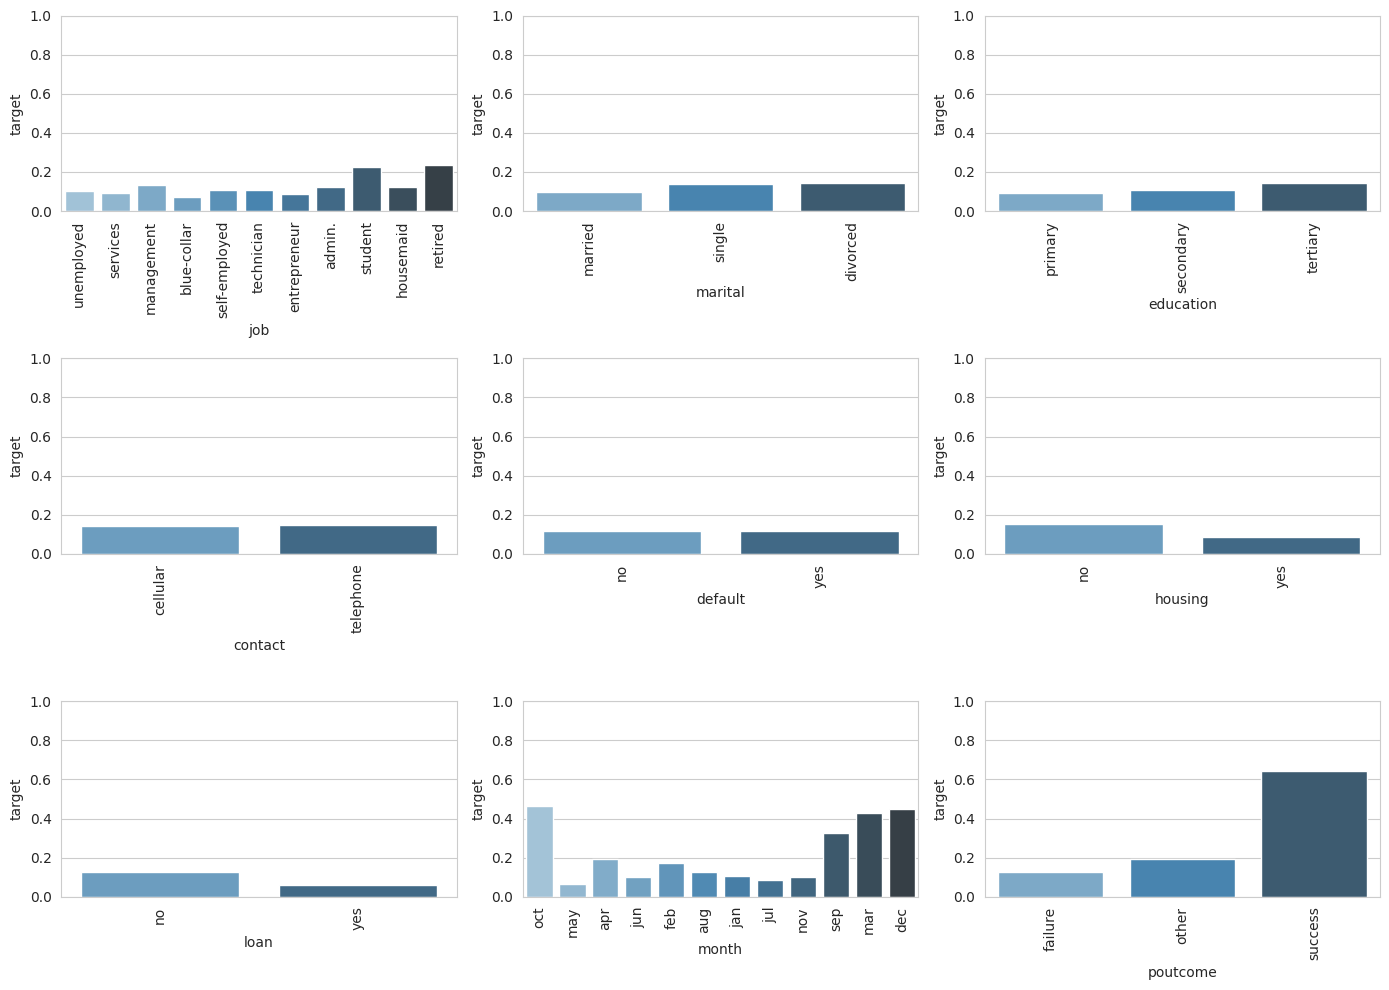

In [19]:
cat_features = ['job', 'marital', 'education', 'contact', 'default', 'housing', 'loan', 'month', 'poutcome']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.barplot(data=bank, x=col, y='target', ax=axes[i], palette='Blues_d', legend=False, errorbar=None)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.show()

---

**Ответьте на вопросы:**

**Вопрос:** Люди каких профессий чаще открывают депозит?

**Ответ:** студенты (students) и ушедшие на пенсию (retired)

**Вопрос:** Влияет ли семейное положение на вероятность открытия депозита?

**Ответ:** да, но незначительно - меньше всего открывают люди в браке (married)

**Вопрос:** Какой тип связи (contact) наиболее эффективен?

**Ответ:** оба?

**Вопрос:** Какие в общем категории клиентов чаще открывают вклад (примерный портрет по всем категориальным признакам в совокупности)?

**Ответ:** студенты/ушедшие на пенсию, в разводе/холостые, имеющие высшее образование. Исход прошлой компании - успешный. Открывают вклад в октябре/декабре/марте. Личного кредита и ипотеки нет

---

### ****Задание 3.5. Анализ связей между признаками (Boxplot)****

> 📚 **Подсказка:** Использование boxplot для анализа распределений показано в [**Занятии 2, Часть 2.6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=592b07cc).

**Постройте `boxplot` для анализа баланса по уровню образования**

<Axes: xlabel='education', ylabel='balance'>

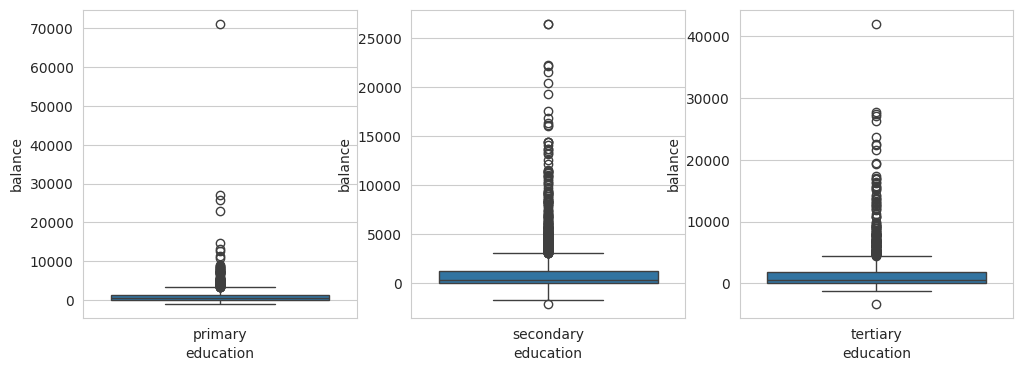

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.boxplot(bank[bank['education'] == 'primary'], x='education', y='balance', ax=axes[0])
sns.boxplot(bank[bank['education'] == 'secondary'], x='education', y='balance', ax=axes[1])
sns.boxplot(bank[bank['education'] == 'tertiary'], x='education', y='balance', ax=axes[2])

**Вопрос:** Различается ли баланс у клиентов с разным образованием?

**Ответ:** разница почти незаметна, но она есть - у клиентов с высшим образованием наблюдается наибольший баланс

---

### ****Задание 3.6. Группировка данных****

> 📚 **Подсказка:** Метод `groupby()` подробно разобран в [**Занятии 1, Часть 3.7**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=baa512e4).

**Вычислите средний баланс и долю открывших депозит по типу работы**

In [21]:
display(bank.groupby('job')['balance'].mean())
bank.groupby('job')['target'].sum() / bank.groupby('job')['target'].size()

,balance
job,
admin.,1226.736402
blue-collar,1085.161734
entrepreneur,1645.125000
housemaid,2083.803571
management,1766.928793
retired,2319.191304
self-employed,1392.409836
services,1103.956835
student,1543.821429


,target
job,
admin.,0.121339
blue-collar,0.072939
entrepreneur,0.089286
housemaid,0.125000
management,0.135191
retired,0.234783
self-employed,0.109290
services,0.091127
student,0.226190


**Вычислите долю открывших депозит по уровню образования**

In [22]:
bank.groupby('education')['target'].sum() / bank.groupby('education')['target'].size()

,target
education,
primary,0.094395
secondary,0.106245
tertiary,0.142963


---

## ****Часть 4. Формулировка гипотез и план экспериментов****

> 📚 **Подсказка:** Формулировка гипотез на основе EDA описана в [**Занятии 2, Часть 3**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=329f49e7).

На основе проведённого EDA сформулируйте **минимум 3 гипотезы** о том, какие признаки и преобразования могут улучшить модель.

### ****Ваши гипотезы:****

(Дважды нажмите правой кнопкой мыши на ячейку ниже, чтобы вписать свои гипотезы)

| № | Наблюдение из EDA | Гипотеза | Как проверить | Метрика для сравнения |
|---|-------------------|----------|---------------|----------------------|
| 1 | `poutcome` отсутствует у большинства данных | Данные могут быть важны | Создать `poutcome_unknown`, сравнить точность | Accuracy, F1 |
| 2 | `balance` имеет отрицательные значения | Создать признак `has_positive_balance` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| 3 | Много категориальных признаков | One-Hot Encoding улучшит модель | `pd.get_dummies()`, сравнить accuracy | Accuracy, F1 |
| 4 | `pdays` = -1 означает "не контактировали" | Создать бинарный признак `was_contacted` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| 5 | `previous` = 0 означает "первый контакт" | Создать бинарный признак `first_contact` | Добавить признак, сравнить accuracy | Accuracy, F1 |

**Примеры формулировок (для ориентира):**

| Наблюдение | Гипотеза | Как проверить | Метрика |
|------------|----------|---------------|---------|
| `duration` сильно различается у классов | Признак важен для предсказания | Сравнить accuracy с `duration` и без него | Accuracy, F1 |
| `pdays` = -1 означает "не контактировали" | Создать бинарный признак `was_contacted` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| `balance` имеет отрицательные значения | Создать признак `has_positive_balance` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| В `job` есть пропуски | Факт пропуска может быть информативен | Создать `job_unknown`, сравнить accuracy | Accuracy, F1 |
| Много категориальных признаков | One-Hot Encoding улучшит модель | `pd.get_dummies()`, сравнить accuracy | Accuracy, F1 |

> 📚 **Подсказка:** Методология проверки гипотез через эксперименты подробно разобрана в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

---

## ****Часть 5. Сравнение методов классификации****

> 📚 **Подсказка:** Различные методы классификации (логистическая регрессия, деревья решений, ансамбли, SVM, KNN) подробно разбирались на занятиях по supervised learning.

### ****5.1. Расширенная функция оценки модели****

> 📚 **Подсказка:** Базовая функция `evaluate_model()` была создана в [**Занятии 2, после Части 4.6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=maxKagcsxhv8).

In [23]:
def evaluate_model_advanced(model, X, y, model_name="Model"):
    """
    Расширенная оценка модели с множественными метриками.

    Параметры:
    ----------
    model : sklearn estimator
        Модель для обучения и оценки
    X : DataFrame или array
        Признаки
    y : Series или array
        Целевая переменная
    model_name : str
        Название модели для отображения

    Возвращает:
    -----------
    dict : словарь с метриками
    """
    # 1. Разделение данных (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # 2. Масштабирование (ВАЖНО: fit только на train!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. Обучение модели
    model.fit(X_train_scaled, y_train)

    # 4. Предсказание
    y_pred = model.predict(X_test_scaled)

    # 5. Вероятности (если модель поддерживает)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc_auc = None

    # 6. Расчёт метрик
    results = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc
    }

    return results, y_test, y_pred, y_proba

### ****5.2. Простая функция оценки (для быстрых экспериментов)****

In [24]:
def evaluate_model(X, y):
    """
    Быстрая оценка модели логистической регрессии.
    Возвращает только accuracy.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

### ****5.3. Подготовка данных для baseline****

In [25]:
# Выбираем только числовые признаки для baseline
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Подготовьте X и y
X_baseline = bank[numeric_cols]
y_baseline = bank['target']

print(f"Размер X: {X_baseline.shape}")
print(f"Размер y: {y_baseline.shape}")

Размер X: (4521, 7)
Размер y: (4521,)


### ****5.4. Задание: Сравните ВСЕ методы классификации****

**Создайте словарь со всеми моделями:**

In [26]:
# Словарь моделей для сравнения
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42, algorithm='SAMME'),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

**Обучите все модели и соберите результаты:**

In [27]:
comparison_results = []

print("=" * 70)
print("СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАССИФИКАЦИИ (BASELINE)")
print("=" * 70)

for name, model in models.items():
    res, y_test, y_pred, y_proba = evaluate_model_advanced(model, X_baseline, y_baseline, name)
    comparison_results.append(res)
    print(f"{name:25} | Accuracy: {res['accuracy']:.4f} | F1: {res['f1']:.4f} | ROC-AUC: ", f"{res['roc_auc']:.4f}" if res['roc_auc'] else 'N/A')

print("=" * 70)

СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАССИФИКАЦИИ (BASELINE)
Logistic Regression       | Accuracy: 0.8862 | F1: 0.2370 | ROC-AUC:  0.8162
Decision Tree             | Accuracy: 0.8475 | F1: 0.3365 | ROC-AUC:  0.6252
Random Forest             | Accuracy: 0.8729 | F1: 0.2857 | ROC-AUC:  0.8449
Gradient Boosting         | Accuracy: 0.8807 | F1: 0.3494 | ROC-AUC:  0.8491
AdaBoost                  | Accuracy: 0.8807 | F1: 0.2800 | ROC-AUC:  0.8366
SVM                       | Accuracy: 0.8873 | F1: 0.1639 | ROC-AUC:  0.7408
KNN                       | Accuracy: 0.8917 | F1: 0.3718 | ROC-AUC:  0.7192
Naive Bayes               | Accuracy: 0.8575 | F1: 0.3768 | ROC-AUC:  0.8009


###<summary><b>Подсказка (код):</b></summary>

In [28]:
comparison_results = []

print("=" * 70)
print("СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАССИФИКАЦИИ (BASELINE)")
print("=" * 70)

for name, model in models.items():
    results, _, _, _ = evaluate_model_advanced(model, X_baseline, y_baseline, name)
    comparison_results.append(results)
    print(f"{name:25} | Accuracy: {results['accuracy']:.4f} | F1: {results['f1']:.4f} | ROC-AUC: ", f"{res['roc_auc']:.4f}" if res['roc_auc'] else 'N/A')

print("=" * 70)

СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАССИФИКАЦИИ (BASELINE)
Logistic Regression       | Accuracy: 0.8862 | F1: 0.2370 | ROC-AUC:  0.8009
Decision Tree             | Accuracy: 0.8475 | F1: 0.3365 | ROC-AUC:  0.8009
Random Forest             | Accuracy: 0.8729 | F1: 0.2857 | ROC-AUC:  0.8009
Gradient Boosting         | Accuracy: 0.8807 | F1: 0.3494 | ROC-AUC:  0.8009
AdaBoost                  | Accuracy: 0.8807 | F1: 0.2800 | ROC-AUC:  0.8009
SVM                       | Accuracy: 0.8873 | F1: 0.1639 | ROC-AUC:  0.8009
KNN                       | Accuracy: 0.8917 | F1: 0.3718 | ROC-AUC:  0.8009
Naive Bayes               | Accuracy: 0.8575 | F1: 0.3768 | ROC-AUC:  0.8009


</details>

### ****5.5. Создайте DataFrame с результатами и визуализируйте****

In [29]:
df_comparison = pd.DataFrame.from_records(comparison_results)
df_comparison.sort_values('f1', ascending=False)

,model_name,accuracy,precision,recall,f1,roc_auc
7,Naive Bayes,0.857459,0.378641,0.375000,0.376812,0.800862
6,KNN,0.891713,0.557692,0.278846,0.371795,0.719167
3,Gradient Boosting,0.880663,0.467742,0.278846,0.349398,0.849101
1,Decision Tree,0.847514,0.336538,0.336538,0.336538,0.625198
2,Random Forest,0.872928,0.403509,0.221154,0.285714,0.844947
4,AdaBoost,0.880663,0.456522,0.201923,0.280000,0.836604
0,Logistic Regression,0.886188,0.516129,0.153846,0.237037,0.816191
5,SVM,0.887293,0.555556,0.096154,0.163934,0.740787


**Постройте визуализацию сравнения моделей:**

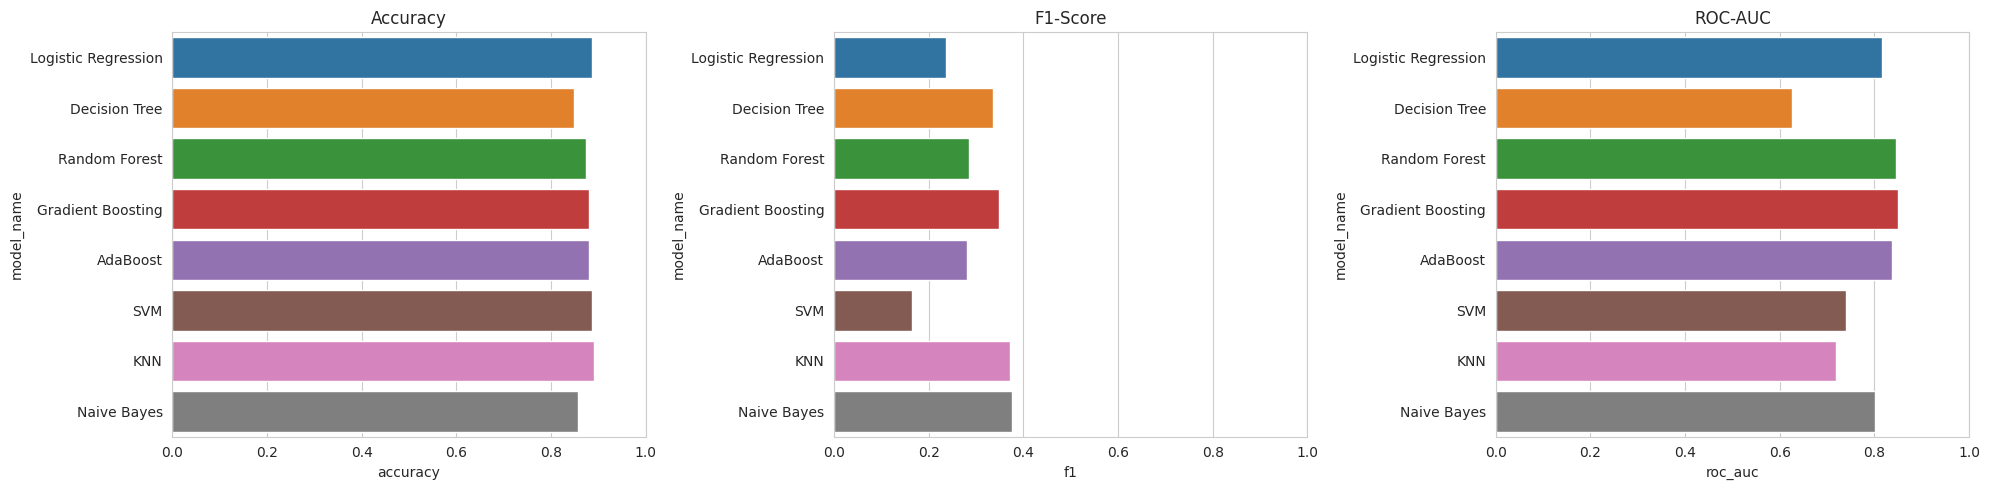

In [30]:
# Постройте barplot для сравнения моделей по разным метрикам
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

metrics_to_plot = ['accuracy', 'f1', 'roc_auc']
titles = ['Accuracy', 'F1-Score', 'ROC-AUC']

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)): #горизонтально, чтобы помещались названия моделей
  sns.barplot(data=df_comparison, x=metric, y='model_name', hue='model_name', ax=axes[i], legend=False)
  axes[i].set_title(title)
  axes[i].set_xlim(0, 1)

plt.tight_layout()
plt.show()

### ****5.6. Ответьте на вопросы****

**Вопрос:** Какие 3 модели показали лучший результат по F1-Score?

**Ответ:** Naive Bayes, KNN, Gradient Boosting

**Вопрос:** Почему мы ориентируемся на F1-Score, а не на Accuracy? (Подсказка: вспомните баланс классов)

**Ответ:** Потому что классы находятся в дисбалансе. Слишком много классов "no" и мало "yes"

**Вопрос:** Какая модель показала лучший ROC-AUC? Что это означает?

**Ответ:** Gradient Boosting. Это означает то, что она лучше всех различает классы

---

## ****Часть 6. Стратегии обработки пропусков****

> 📚 **Подсказка:** Стратегии заполнения пропусков (удаление, заполнение модой/медианой, создание признаков) подробно разобраны в [**Занятии 2, Часть 5**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=89cec4d9).

### ****6.1. Стратегия A: Удаление строк с пропусками****

In [31]:
df_dropped = bank.dropna()

print(f"Было строк: {len(bank)}")
print(f"Стало строк: {len(df_dropped)}")
print(f"Потеряно: {len(bank) - len(df_dropped)} ({(len(bank) - len(df_dropped)) / len(bank) * 100:.1f}%)")

Было строк: 4521
Стало строк: 764
Потеряно: 3757 (83.1%)


**Вопрос:** Приемлемо ли терять столько данных?

**Ответ:** нет, высоки шансы недообучения моделей

---

### ****6.2. Стратегия B: Заполнение модой****

> 📚 **Подсказка:** Заполнение пропусков модой через `fillna()` рассматривалось в [**Занятии 2, Часть 5, Стратегия B**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=8e470458).

**Заполните категориальные пропуски модой (самым частым значением)**

In [32]:
df_filled = bank.copy()

cat_cols_with_na = ['job', 'education', 'contact', 'poutcome']

for col in cat_cols_with_na:
    if df_filled[col].isna().sum() > 0:
        mode_value = df_filled[col].mode()[0]
        df_filled[col] = df_filled[col].fillna(mode_value)

print(f"Пропусков после заполнения: {df_filled.isna().sum().sum()}")

Пропусков после заполнения: 0


### ****6.3. Стратегия C: Создание признаков из пропусков****

> 📚 **Подсказка:** Создание бинарных признаков из пропусков (например, `has_cabin` в Titanic) рассматривалось в [**Занятии 2, Часть 6, Эксперимент 2, Тест D**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=df9d9180).
>
> **Идея:** Сам факт того, что значение неизвестно, может быть информативен! Например: если клиент не указал профессию — это может что-то говорить о нём.

**Создайте признаки "был ли пропуск" ДО заполнения**

In [33]:
df_fe = bank.copy()
df_fe['job_unknown'] = bank['job'].isna().astype(int)
df_fe['education_unknown'] = bank['education'].isna().astype(int)
df_fe['contact_unknown'] = bank['contact'].isna().astype(int)
df_fe['poutcome_unknown'] = bank['poutcome'].isna().astype(int)

df_fe

,age,job,marital,education,default,balance,housing,loan,contact,day,...,campaign,pdays,previous,poutcome,y,target,job_unknown,education_unknown,contact_unknown,poutcome_unknown
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,...,1,-1,0,NaN,no,0,0,0,0,1
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,...,1,339,4,failure,no,0,0,0,0,0
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,...,1,330,1,failure,no,0,0,0,0,0
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,...,4,-1,0,NaN,no,0,0,0,1,1
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,...,1,-1,0,NaN,no,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,...,5,-1,0,NaN,no,0,0,0,0,1
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,NaN,9,...,1,-1,0,NaN,no,0,0,0,1,1
4518,57,technician,married,secondary,no,295,no,no,cellular,19,...,11,-1,0,NaN,no,0,0,0,0,1
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,...,4,211,3,other,no,0,0,0,0,0


---

## ****Часть 7. Feature Engineering и отбор признаков****

> 📚 **Подсказка:** Создание новых признаков на основе анализа данных описано в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

### ****7.1. Создание новых признаков****

**Создайте следующие признаки на основе гипотез из EDA:**

In [49]:
df_fe = bank.copy()

# 1. Был ли клиент контактирован ранее (pdays != -1)
df_fe['was_contacted'] = (bank['pdays'] != -1).astype(int)

# 2. Положительный баланс
df_fe['has_positive_balance'] = (bank['balance'] > 0).astype(int)

# 3. Признаки из пропусков (ДО заполнения!)
df_fe['job_unknown'] = bank['job'].isna().astype(int)
df_fe['education_unknown'] = bank['education'].isna().astype(int)
df_fe['contact_unknown'] = bank['contact'].isna().astype(int)

# Теперь заполняем пропуски
for col in ['job', 'education', 'contact']:
    if df_fe[col].isna().sum() > 0:
        mode_value = df_fe[col].mode()[0]
        df_fe[col] = df_fe[col].fillna(mode_value)

print("Созданные признаки:")
df_fe[['was_contacted', 'has_positive_balance', 'job_unknown', 'education_unknown', 'contact_unknown']].head(10)

Созданные признаки:


,was_contacted,has_positive_balance,job_unknown,education_unknown,contact_unknown
0,0,1,0,0,0
1,1,1,0,0,0
2,1,1,0,0,0
3,0,1,0,0,1
4,0,0,0,0,1
5,1,1,0,0,0
6,1,1,0,0,0
7,0,1,0,0,0
8,0,1,0,0,1
9,1,0,0,0,0


**Добавьте свои признаки на основе ваших гипотез:**

In [50]:
df_fe2 = df_fe.copy()

# One-Hot Encoding
df_fe2 = pd.get_dummies(df_fe, columns=['job', 'marital', 'education', 'contact', 'default', 'housing', 'loan', 'month', 'poutcome'], drop_first=True)

# Признак: был ли пропуск в poutcome
df_fe2['poutcome_unknown'] = bank['poutcome'].isna().astype(int)

# Признак: первый ли контакт с клиентом (previous == 0)
df_fe2['first_contact'] = (bank['previous'] == 0).astype(int)

print("Созданные признаки:")
print(df_fe2.columns.difference(df_fe.columns).tolist())

df_fe = df_fe2.copy()

Созданные признаки:
['contact_telephone', 'default_yes', 'education_secondary', 'education_tertiary', 'first_contact', 'housing_yes', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'loan_yes', 'marital_married', 'marital_single', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


### ****7.2. Систематический перебор комбинаций признаков****

> **Цель:** Определить, какие признаки улучшают модель, а какие вносят шум.

**Определите базовый набор признаков и признаки для тестирования:**

In [36]:
# Базовые числовые признаки
base_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']

# Новые созданные признаки для тестирования
new_features = ['was_contacted', 'has_positive_balance', 'job_unknown',
                'education_unknown', 'contact_unknown', 'first_contact',
                'poutcome_unknown']
oneh_features = ['housing_yes', 'job_blue-collar', 'job_entrepreneur',
                'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
                'job_services', 'job_student', 'job_technician', 'job_unemployed',
                'loan_yes', 'marital_married', 'marital_single', 'month_aug',
                'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
                'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
                'poutcome_other', 'poutcome_success', 'contact_telephone',
                'default_yes', 'education_secondary', 'education_tertiary']

X_base = df_fe[base_features]
y = df_fe['target']

accuracy_base = evaluate_model(X_base, y)
print(f"Базовая модель ({len(base_features)} признаков): Accuracy = {accuracy_base:.4f}")
print(f"Признаки: {base_features}")
print("=" * 60)

Базовая модель (7 признаков): Accuracy = 0.8862
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']


**Протестируйте добавление каждого нового признака по отдельности:**

In [37]:
accuracies = {}

for i in new_features:
  features = base_features.copy()
  features.append(i)
  X = df_fe[features]
  y = df_fe['target']
  accuracy_fe = evaluate_model(X, y)
  accuracies[i] = accuracy_fe
  print(f"Модель ({len(features)} признаков): Accuracy = {accuracy_fe:.4f}")
  print(f"Признаки: {features}")
  print("=" * 60)

features_fe = base_features.copy()
features_fe.append(oneh_features)
X_fe = df_fe[features]
y_fe = df_fe['target']
accuracy_fe = evaluate_model(X_fe, y_fe)
accuracies['One-Hot'] = accuracy_fe
print(f"Модель ({len(features_fe)} признаков): Accuracy = {accuracy_fe:.4f}")
print(f"Признаки: {features_fe}")
print("=" * 60)

pd.DataFrame.from_dict(accuracies, orient='index')

Модель (8 признаков): Accuracy = 0.8917
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'was_contacted']
Модель (8 признаков): Accuracy = 0.8862
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'has_positive_balance']
Модель (8 признаков): Accuracy = 0.8862
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'job_unknown']
Модель (8 признаков): Accuracy = 0.8862
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'education_unknown']
Модель (8 признаков): Accuracy = 0.8818
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'contact_unknown']
Модель (8 признаков): Accuracy = 0.8917
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'first_contact']
Модель (8 признаков): Accuracy = 0.8917
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'poutcome_unknown']
Модель (8 признаков)

,0
was_contacted,0.891713
has_positive_balance,0.886188
job_unknown,0.886188
education_unknown,0.886188
contact_unknown,0.881768
first_contact,0.891713
poutcome_unknown,0.891713
One-Hot,0.891713


**Вопрос:** Какие признаки улучшили модель? Какие ухудшили (внесли шум)?

**Ответ:** Ухудшил признак `contact_unknown`, не поменяли никак `has_positive_balance`,`job_unknown`,`education_unknown`, остальные - улучшили

### ****7.3. Анализ важности признаков с помощью Random Forest****

ВАЖНОСТЬ ПРИЗНАКОВ (Random Forest)
             feature  importance
            duration    0.262358
                 age    0.095157
             balance    0.094221
                 day    0.084828
    poutcome_success    0.044392
            campaign    0.042080
               pdays    0.035564
            previous    0.018337
         housing_yes    0.017935
           month_oct    0.016538
     marital_married    0.016486
 education_secondary    0.015654
  education_tertiary    0.013452
     contact_unknown    0.013318
           month_aug    0.013286
      job_technician    0.012472
           month_jun    0.012460
      job_management    0.012158
           month_may    0.011872
           month_mar    0.011508
      marital_single    0.011453
     job_blue-collar    0.010521
           month_nov    0.009954
           month_feb    0.009376
            loan_yes    0.009168
   contact_telephone    0.009097
           month_jul    0.008972
has_positive_balance    0.008668
        

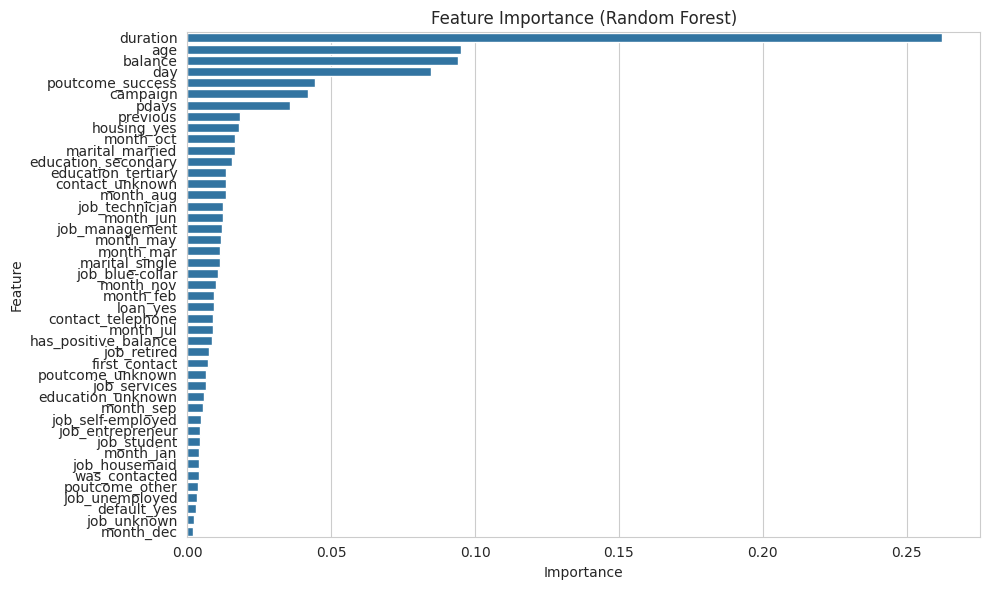

In [38]:
# Соберём все признаки
all_numeric_features = base_features + new_features
all_numeric_features += oneh_features
X_all = df_fe[all_numeric_features]

# Обучим Random Forest и посмотрим важность признаков
from sklearn.ensemble import RandomForestClassifier

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Обучение
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

# Важность признаков
importance_df = pd.DataFrame({
    'feature': all_numeric_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("ВАЖНОСТЬ ПРИЗНАКОВ (Random Forest)")
print("=" * 40)
print(importance_df.to_string(index=False))
print("=" * 40)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### ****7.4. Рекурсивное исключение признаков (RFE)****

> 📚 **Подсказка:** [RFE](https://habr.com/ru/companies/otus/articles/528676/) автоматически отбирает наиболее важные признаки, последовательно удаляя наименее значимые.

In [39]:
from sklearn.feature_selection import RFE

# Применяем RFE для отбора лучших признаков
selector = RFE(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    n_features_to_select=7,
    step=1
)

selector.fit(X_scaled, y)

selected_features = [f for f, s in zip(all_numeric_features, selector.support_) if s]
rejected_features = [f for f, s in zip(all_numeric_features, selector.support_) if not s]

print("РЕЗУЛЬТАТЫ RFE")
print("=" * 40)
print(f"Отобранные признаки ({len(selected_features)}): {selected_features}")
print(f"Отвергнутые признаки ({len(rejected_features)}): {rejected_features}")
print("=" * 40)

X_selected = df_fe[selected_features]
accuracy_selected = evaluate_model(X_selected, y)
accuracy_all = evaluate_model(X_all, y)

print(f"\nAccuracy (все {len(all_numeric_features)} признаков): {accuracy_all:.4f}")
print(f"Accuracy (отобранные {len(selected_features)} признаков): {accuracy_selected:.4f}")
print(f"Разница: {accuracy_selected - accuracy_all:+.4f}")

РЕЗУЛЬТАТЫ RFE
Отобранные признаки (7): ['duration', 'contact_unknown', 'month_aug', 'month_jul', 'month_may', 'month_nov', 'poutcome_success']
Отвергнутые признаки (38): ['age', 'balance', 'campaign', 'pdays', 'previous', 'day', 'was_contacted', 'has_positive_balance', 'job_unknown', 'education_unknown', 'first_contact', 'poutcome_unknown', 'housing_yes', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'loan_yes', 'marital_married', 'marital_single', 'month_dec', 'month_feb', 'month_jan', 'month_jun', 'month_mar', 'month_oct', 'month_sep', 'poutcome_other', 'contact_telephone', 'default_yes', 'education_secondary', 'education_tertiary']

Accuracy (все 45 признаков): 0.8917
Accuracy (отобранные 7 признаков): 0.8983
Разница: +0.0066


**Вопрос:** Помог ли отбор признаков улучшить модель? Какие признаки оказались лишними?

**Ответ:** немного, но помог. Оказались лишними все, кроме `duration`, `contact_unknown`, `month_aug`, `month_jul`, `month_may`, `month_nov`, `poutcome_success`

---

## ****Часть 8. Кодирование категориальных признаков****

> 📚 **Подсказка:** One-Hot Encoding для категориальных признаков рассматривался в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

### ****8.1. Примените One-Hot Encoding****

In [53]:
#One-Hot Encoding был в 7.1

### ****8.2. Подготовьте финальный набор признаков****

In [54]:
cols_to_drop = ['y', 'target']
X_final = df_fe.drop(columns=cols_to_drop)
y_final = df_fe['target']

print(f"Финальный размер X: {X_final.shape}")
print(f"Количество признаков: {X_final.shape[1]}")

Финальный размер X: (4521, 45)
Количество признаков: 45


### ****8.3. Сравните модели на расширенном наборе признаков****

In [ ]:
print("=" * 70)
print("СРАВНЕНИЕ МОДЕЛЕЙ НА РАСШИРЕННОМ НАБОРЕ ПРИЗНАКОВ")
print("=" * 70)

comparison_results_extended = []

for name, model in models.items():
    # Создаём новый экземпляр модели
    if name == 'Logistic Regression':
        model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    elif name == 'Decision Tree':
        model = DecisionTreeClassifier(random_state=42)
    elif name == 'Random Forest':
        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    elif name == 'Gradient Boosting':
        model = GradientBoostingClassifier(random_state=42)
    elif name == 'AdaBoost':
        model = AdaBoostClassifier(random_state=42, algorithm='SAMME')
    elif name == 'SVM':
        model = SVC(probability=True, random_state=42)
    elif name == 'KNN':
        model = KNeighborsClassifier(n_jobs=-1)
    elif name == 'Naive Bayes':
        model = GaussianNB()

    results, _, _, _ = evaluate_model_advanced(model, X_final, y_final, name)
    comparison_results_extended.append(results)
    print(f"{name:25} | Accuracy: {results['accuracy']:.4f} | F1: {results['f1']:.4f} | ROC-AUC: ", f"{res['roc_auc']:.4f}" if res['roc_auc'] else 'N/A')

print("=" * 70)

# Создайте DataFrame и отсортируйте по F1
df_comparison_extended = pd.DataFrame(comparison_results_extended)
df_comparison_extended = df_comparison_extended.sort_values('f1', ascending=False)
print("\nРАНЖИРОВАНИЕ ПО F1-SCORE:")
print(df_comparison_extended[['model_name', 'accuracy', 'f1', 'roc_auc']].to_string(index=False))

СРАВНЕНИЕ МОДЕЛЕЙ НА РАСШИРЕННОМ НАБОРЕ ПРИЗНАКОВ
Logistic Regression       | Accuracy: 0.8917 | F1: 0.3951 | ROC-AUC:  0.8009
Decision Tree             | Accuracy: 0.8564 | F1: 0.4144 | ROC-AUC:  0.8009
Random Forest             | Accuracy: 0.8862 | F1: 0.3179 | ROC-AUC:  0.8009
Gradient Boosting         | Accuracy: 0.8895 | F1: 0.4382 | ROC-AUC:  0.8009
AdaBoost                  | Accuracy: 0.8906 | F1: 0.3774 | ROC-AUC:  0.8009
SVM                       | Accuracy: 0.8840 | F1: 0.2857 | ROC-AUC:  0.8009
KNN                       | Accuracy: 0.8884 | F1: 0.3129 | ROC-AUC:  0.8009
Naive Bayes               | Accuracy: 0.8177 | F1: 0.3678 | ROC-AUC:  0.8009

РАНЖИРОВАНИЕ ПО F1-SCORE:
         model_name  accuracy       f1  roc_auc
  Gradient Boosting  0.889503 0.438202 0.899183
      Decision Tree  0.856354 0.414414 0.676210
Logistic Regression  0.891713 0.395062 0.891806
           AdaBoost  0.890608 0.377358 0.877023
        Naive Bayes  0.817680 0.367816 0.783972
      Random Forest

---

## ****Часть 9. Выбор топ-3 моделей****

### ****9.1. Определите топ-3 модели по F1-Score****

In [ ]:
# Выберите топ-3 модели из df_comparison_extended
top_3_models = df_comparison_extended.head(3)['model_name'].tolist()

print("ТОП-3 МОДЕЛИ ПО F1-SCORE:")
print("=" * 40)
for i, model_name in enumerate(top_3_models, 1):
    row = df_comparison_extended[df_comparison_extended['model_name'] == model_name].iloc[0]
    print(f"{i}. {model_name}: F1 = {row['f1']:.4f}, ROC-AUC = {row['roc_auc']:.4f}")
print("=" * 40)

ТОП-3 МОДЕЛИ ПО F1-SCORE:
1. Gradient Boosting: F1 = 0.4382, ROC-AUC = 0.8992
2. Decision Tree: F1 = 0.4144, ROC-AUC = 0.6762
3. Logistic Regression: F1 = 0.3951, ROC-AUC = 0.8918


### ****9.2. Постройте ROC-кривые для топ-3 моделей****

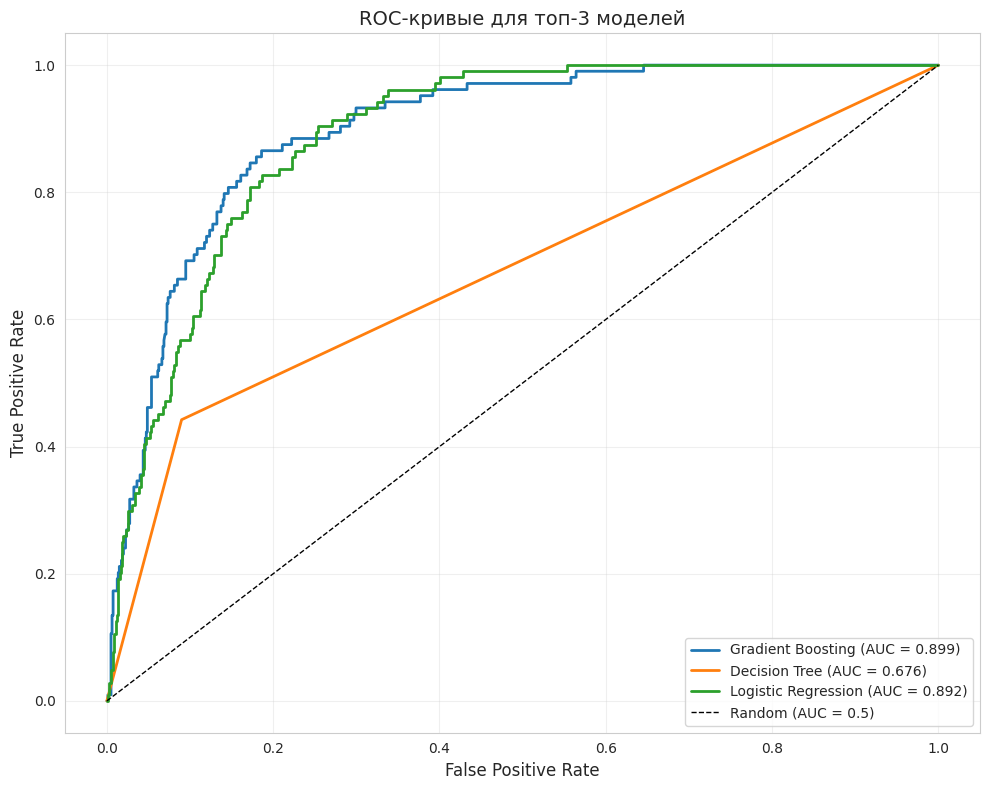

In [ ]:
from sklearn.metrics import roc_curve, auc

# Подготовка данных
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Словарь для топ-3 моделей
top_3_model_objects = {}
for name in top_3_models:
    if name == 'Logistic Regression':
        top_3_model_objects[name] = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    elif name == 'Random Forest':
        top_3_model_objects[name] = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    elif name == 'Gradient Boosting':
        top_3_model_objects[name] = GradientBoostingClassifier(random_state=42)
    elif name == 'AdaBoost':
        top_3_model_objects[name] = AdaBoostClassifier(random_state=42, algorithm='SAMME')
    elif name == 'Decision Tree':
        top_3_model_objects[name] = DecisionTreeClassifier(random_state=42)
    elif name == 'SVM':
        top_3_model_objects[name] = SVC(probability=True, random_state=42)
    elif name == 'KNN':
        top_3_model_objects[name] = KNeighborsClassifier(n_jobs=-1)
    elif name == 'Naive Bayes':
        top_3_model_objects[name] = GaussianNB(n_jobs=-1)

# Построение ROC-кривых
plt.figure(figsize=(10, 8))

for name, model in top_3_model_objects.items():
    model.fit(X_train_scaled, y_train)

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые для топ-3 моделей', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ****9.3. Постройте Confusion Matrix для топ-3 моделей****

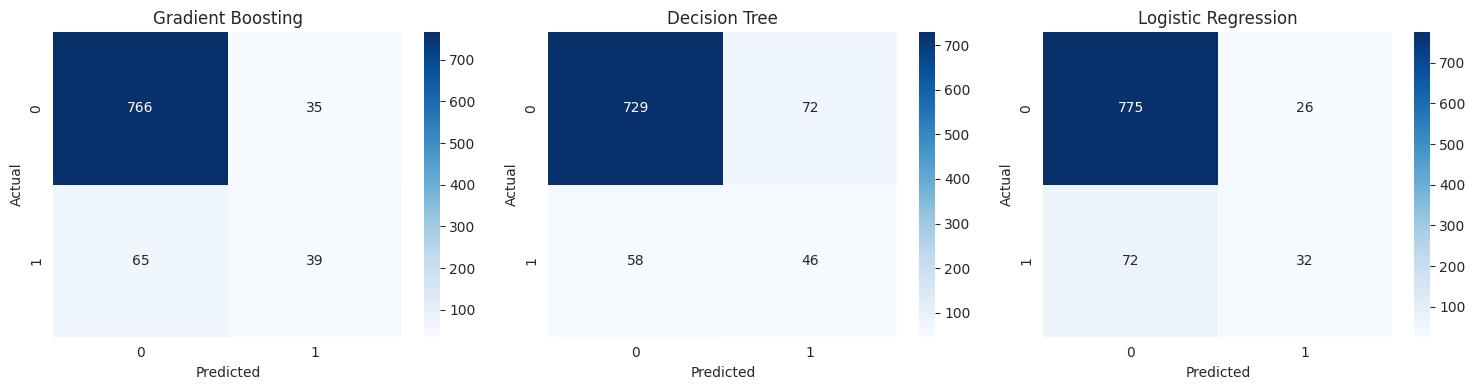

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, model) in enumerate(top_3_model_objects.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**Вопрос:** Какая модель лучше всего находит положительный класс (клиентов, которые откроют вклад)?


Ответ: Если судить по метрике Precision (`TP/(FP+TP)`), то лучше всего - Decision Tree, имеет оценку 0,5384 (можно заметить и так, что у этой модел наибольшее кол-во правильный предсказаний - 46 из 104)

---


Модель Gradient Boosting имеет оценку Precision равную 0,375

---


Модель Logistic Regression, с оценкой 0,3076.


---

## ****Часть 10. Оптимизация гиперпараметров с GridSearchCV****

> 📚 **Подсказка:** GridSearchCV перебирает все комбинации гиперпараметров и выбирает лучшую с помощью кросс-валидации.

### ****10.1. Определите сетки гиперпараметров для топ-3 моделей****

In [ ]:
max_depth = [int(i) for i in np.linspace(start=1, stop=80, num=7)]
max_depth.append(None)
gb_params = {'learning_rate': [float(i) for i in np.linspace(start=0.01, stop=3.0, num=7)],
             'max_features': ['log2', 'auto', None],
             'min_samples_leaf': [int(i) for i in np.linspace(start=1, stop=50, num=7)],
             'max_depth': max_depth}

dt_params = {'min_samples_split': [int(i) for i in np.linspace(start=2, stop=100, num=15)],
             'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=100, num=15)],
             'max_depth': max_depth}

lr_params = {'penalty': ['l1', 'l2', 'elasticnet', 'none'],
             'C': [float(i) for i in np.linspace(start=0.01, stop=3.0, num=7)],
             'class_weight': ['balanced', None],
             'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
             'multi_class': ['auto', 'ovr', 'multinomial']}

### ****10.2. Запустите GridSearchCV для каждой модели из топ-3****

In [ ]:
from sklearn.model_selection import GridSearchCV
gs_gb = GridSearchCV(estimator=top_3_model_objects['Gradient Boosting'], param_grid=gb_params, cv=5, n_jobs=-1, verbose=1)
gs_gb.fit(X_train_scaled, y_train)

gb_best = gs_gb.best_estimator_

Fitting 5 folds for each of 1176 candidates, totalling 5880 fits


In [ ]:
gs_dt = GridSearchCV(estimator=top_3_model_objects['Decision Tree'], param_grid=dt_params, cv=5, n_jobs=-1, verbose=1)
gs_dt.fit(X_train_scaled, y_train)
dt_best = gs_dt.best_estimator_

Fitting 5 folds for each of 1800 candidates, totalling 9000 fits


In [ ]:
gs_lr = GridSearchCV(estimator=top_3_model_objects['Logistic Regression'], param_grid=lr_params, cv=5, n_jobs=-1, verbose=1)
gs_lr.fit(X_train_scaled, y_train)
lr_best = gs_lr.best_estimator_

Fitting 5 folds for each of 840 candidates, totalling 4200 fits


In [ ]:
display(gb_best) # для дальнейшего вызова моделей без перезапуска подбора
display(dt_best)
display(lr_best)

GradientBoostingClassifier(learning_rate=0.5083333333333333, max_depth=27,
                           max_features='log2', min_samples_leaf=9,
                           random_state=42)

DecisionTreeClassifier(max_depth=14, max_leaf_nodes=16, min_samples_split=100,
                       random_state=42)

LogisticRegression(C=1.5050000000000001, max_iter=1000, multi_class='auto',
                   n_jobs=-1, penalty='l1', random_state=42,
                   solver='liblinear')

In [ ]:
results = pd.DataFrame(gs_gb.cv_results_)
# Сортировка по лучшему качеству
param_cols = [col for col in results.columns if col.startswith('param_')]
impact = {}
for col in param_cols:
    # Группируем по значению параметра и считаем средний score
    grouped = results.groupby(col)['mean_test_score'].mean()
    # Разница между лучшим и худшим средним значением
    score_diff = grouped.max() - grouped.min()
    param_name = col.replace('param_', '')
    impact[param_name] = score_diff

impact_df = pd.DataFrame.from_dict(impact, orient='index', columns=['score_range'])
impact_df = impact_df.sort_values('score_range', ascending=False)
print(impact_df)

                  score_range
learning_rate        0.216100
max_depth            0.094703
min_samples_leaf     0.075331
max_features         0.000000


In [ ]:
results = pd.DataFrame(gs_dt.cv_results_)
# Сортировка по лучшему качеству
param_cols = [col for col in results.columns if col.startswith('param_')]
impact = {}
for col in param_cols:
    # Группируем по значению параметра и считаем средний score
    grouped = results.groupby(col)['mean_test_score'].mean()
    # Разница между лучшим и худшим средним значением
    score_diff = grouped.max() - grouped.min()
    param_name = col.replace('param_', '')
    impact[param_name] = score_diff

impact_df = pd.DataFrame.from_dict(impact, orient='index', columns=['score_range'])
impact_df = impact_df.sort_values('score_range', ascending=False)
print(impact_df)

                   score_range
max_leaf_nodes        0.011758
max_depth             0.009679
min_samples_split     0.007227


In [ ]:
results = pd.DataFrame(gs_lr.cv_results_)
# Сортировка по лучшему качеству
param_cols = [col for col in results.columns if col.startswith('param_')]
impact = {}
for col in param_cols:
    # Группируем по значению параметра и считаем средний score
    grouped = results.groupby(col)['mean_test_score'].mean()
    # Разница между лучшим и худшим средним значением
    score_diff = grouped.max() - grouped.min()
    param_name = col.replace('param_', '')
    impact[param_name] = score_diff

impact_df = pd.DataFrame.from_dict(impact, orient='index', columns=['score_range'])
impact_df = impact_df.sort_values('score_range', ascending=False)
print(impact_df)

              score_range
C                0.002773
solver           0.001758
penalty          0.001099
multi_class      0.000541
class_weight     0.000000


In [ ]:
# если необходимо иметь модели без перезапуска подбора
# gb_best = GradientBoostingClassifier(learning_rate=0.7575000000000001, max_depth=1,
#                            min_samples_leaf=37, random_state=42)
# gb_best.fit(X_train_scaled, y_train)

# dt_best = DecisionTreeClassifier(max_depth=20, max_leaf_nodes=30, min_samples_split=30,
#                        random_state=42)
# dt_best.fit(X_train_scaled, y_train)

# lr_best = LogisticRegression(C=1.2060000000000002, max_iter=1000, multi_class='auto',
#                    n_jobs=-1, penalty='l1', random_state=42,
#                    solver='liblinear')
# lr_best.fit(X_train_scaled, y_train)

In [ ]:
best_models = {'Gradient Boosting': gb_best, 'Decision Tree': dt_best, 'Logistic Regression': lr_best}
tuning_results = {}
for i, (name, model) in enumerate(best_models.items()):
  res1 = {}
  res1['best_estimator'] = best_models[name]
  res1['f1'] = f1_score(y_test, model.predict(X_test_scaled))
  res1['accuracy'] = accuracy_score(y_test, model.predict(X_test_scaled))
  display(res1)
  tuning_results[name] = res1

{'best_estimator': GradientBoostingClassifier(learning_rate=0.5083333333333333, max_depth=27,
                            max_features='log2', min_samples_leaf=9,
                            random_state=42),
 'f1': 0.36363636363636365,
 'accuracy': 0.8839779005524862}

{'best_estimator': DecisionTreeClassifier(max_depth=14, max_leaf_nodes=16, min_samples_split=100,
                        random_state=42),
 'f1': 0.5539906103286385,
 'accuracy': 0.8950276243093923}

{'best_estimator': LogisticRegression(C=1.5050000000000001, max_iter=1000, multi_class='auto',
                    n_jobs=-1, penalty='l1', random_state=42,
                    solver='liblinear'),
 'f1': 0.39751552795031053,
 'accuracy': 0.8928176795580111}

### ****10.3. Сравните результаты ДО и ПОСЛЕ тюнинга****

In [ ]:
print("=" * 70)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДО И ПОСЛЕ ТЮНИНГА")
print("=" * 70)

comparison_tuning = []

for name in top_3_models:
    # Результаты до тюнинга
    before = df_comparison_extended[df_comparison_extended['model_name'] == name].iloc[0]

    # Результаты после тюнинга
    after = tuning_results.get(name, {})

    if after:
        comparison_tuning.append({
            'Model': name,
            'F1 (до)': before['f1'],
            'F1 (после)': after['f1'],
            'Δ F1': after['f1'] - before['f1'],
            'Accuracy (до)': before['accuracy'],
            'Accuracy (после)': after['accuracy'],
            'Δ Accuracy': after['accuracy'] - before['accuracy']
        })

df_tuning_comparison = pd.DataFrame(comparison_tuning)
print(df_tuning_comparison.to_string(index=False))
print("=" * 70)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДО И ПОСЛЕ ТЮНИНГА
              Model  F1 (до)  F1 (после)      Δ F1  Accuracy (до)  Accuracy (после)  Δ Accuracy
  Gradient Boosting 0.438202    0.363636 -0.074566       0.889503          0.883978   -0.005525
      Decision Tree 0.414414    0.553991  0.139576       0.856354          0.895028    0.038674
Logistic Regression 0.395062    0.397516  0.002454       0.891713          0.892818    0.001105


**Вопрос:** Для какой модели тюнинг дал наибольшее улучшение?

**Ответ:** в прошлых итерациях - для GradientBoosting (~0.49 F1?). Однако в данной итерации - Decision Tree, с улучшением в целых 0.13 по F1 Score (итог - 0.554 F1)

**Вопрос:** Какие гиперпараметры оказали наибольшее влияние на качество?

**Ответ:** Gradient Boosting (по .cv_results_) - гиперпараметр `learning_rate`

Decision Tree - `max_leaf_nodes`

Logistic Regression - `C`

---

## ****Часть 11. Финальное сравнение и выводы****

### ****11.1. Постройте итоговую таблицу всех экспериментов****

In [ ]:
# Соберите все эксперименты в одну таблицу
final_summary = []

# Baseline (только числовые признаки)
baseline_results = df_comparison.iloc[0]  # Лучшая модель на baseline
final_summary.append({
    'Эксперимент': 'Baseline (числовые признаки)',
    'Модель': baseline_results['model_name'],
    'Кол-во признаков': len(numeric_cols),
    'F1-Score': baseline_results['f1'],
    'Accuracy': baseline_results['accuracy']
})

# После Feature Engineering
extended_results = df_comparison_extended.iloc[0]
final_summary.append({
    'Эксперимент': 'Feature Engineering + One-Hot',
    'Модель': extended_results['model_name'],
    'Кол-во признаков': X_final.shape[1],
    'F1-Score': extended_results['f1'],
    'Accuracy': extended_results['accuracy']
})

# После тюнинга (лучшая модель)
best_tuned = max(tuning_results.items(), key=lambda x: x[1]['f1'])
final_summary.append({
    'Эксперимент': 'После GridSearchCV',
    'Модель': f"{best_tuned[0]} (tuned)",
    'Кол-во признаков': X_final.shape[1],
    'F1-Score': best_tuned[1]['f1'],
    'Accuracy': best_tuned[1]['accuracy']
})

df_final_summary = pd.DataFrame(final_summary)
print("=" * 80)
print("ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ")
print("=" * 80)
print(df_final_summary.to_string(index=False))
print("=" * 80)

ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ
                  Эксперимент                Модель  Кол-во признаков  F1-Score  Accuracy
 Baseline (числовые признаки)   Logistic Regression                 7  0.237037  0.886188
Feature Engineering + One-Hot     Gradient Boosting                45  0.438202  0.889503
           После GridSearchCV Decision Tree (tuned)                45  0.553991  0.895028


In [ ]:
importances = dt_best.feature_importances_

feature_importance_df = pd.DataFrame({'Признак': X_final.columns, 'Влияние': importances})
print(feature_importance_df.sort_values(by='Влияние', ascending=False))

                 Признак   Влияние
3               duration  0.485748
42      poutcome_success  0.250008
39             month_oct  0.065334
0                    age  0.050497
36             month_mar  0.036362
5                  pdays  0.035443
35             month_jun  0.032753
11       contact_unknown  0.026984
1                balance  0.016871
4               campaign  0.000000
2                    day  0.000000
7          was_contacted  0.000000
6               previous  0.000000
12       job_blue-collar  0.000000
10     education_unknown  0.000000
9            job_unknown  0.000000
8   has_positive_balance  0.000000
13      job_entrepreneur  0.000000
14         job_housemaid  0.000000
15        job_management  0.000000
16           job_retired  0.000000
21        job_unemployed  0.000000
22       marital_married  0.000000
23        marital_single  0.000000
24   education_secondary  0.000000
17     job_self-employed  0.000000
18          job_services  0.000000
19           job_stu

### ****11.2. Визуализируйте прогресс улучшения модели****

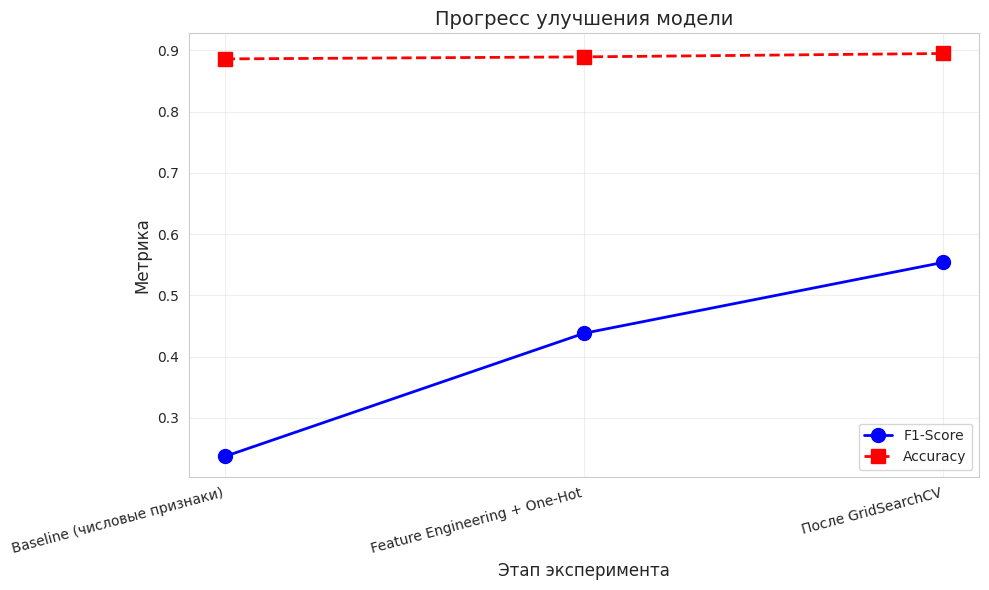


ОБЩИЙ ПРИРОСТ:
F1-Score: 0.2370 → 0.5540 (+0.3170)
Accuracy: 0.8862 → 0.8950 (+0.0088)


In [ ]:
# График прогресса
plt.figure(figsize=(10, 6))

x = range(len(df_final_summary))
plt.plot(x, df_final_summary['F1-Score'], 'bo-', markersize=10, linewidth=2, label='F1-Score')
plt.plot(x, df_final_summary['Accuracy'], 'rs--', markersize=10, linewidth=2, label='Accuracy')

plt.xticks(x, df_final_summary['Эксперимент'], rotation=15, ha='right')
plt.xlabel('Этап эксперимента', fontsize=12)
plt.ylabel('Метрика', fontsize=12)
plt.title('Прогресс улучшения модели', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Прирост
print(f"\nОБЩИЙ ПРИРОСТ:")
print(f"F1-Score: {df_final_summary.iloc[0]['F1-Score']:.4f} → {df_final_summary.iloc[-1]['F1-Score']:.4f} ({df_final_summary.iloc[-1]['F1-Score'] - df_final_summary.iloc[0]['F1-Score']:+.4f})")
print(f"Accuracy: {df_final_summary.iloc[0]['Accuracy']:.4f} → {df_final_summary.iloc[-1]['Accuracy']:.4f} ({df_final_summary.iloc[-1]['Accuracy'] - df_final_summary.iloc[0]['Accuracy']:+.4f})")

### ****11.3. Ответьте на итоговые вопросы****

---

**Вопрос 1:** Какая модель показала лучший финальный результат и почему, по вашему мнению?

**Ответ:** Decision Tree

---

**Вопрос 2:** Какие признаки оказались шумовыми (ухудшали модель)?

**Ответ:** большинство из `month` (кроме oct, jun, mar), `day`, `education`, `job`, `loan`, `campaign`, `contact` (кроме contact_unknown), `marital` (проще, в общем, перечислить те, которые были полезными)

---

**Вопрос 3:** Насколько Feature Engineering улучшил результат по сравнению с baseline?

**Ответ:** Намного, в целых ~0.3 по F1 Score.

---

**Вопрос 4:** Насколько GridSearchCV улучшил результат? Стоило ли это затраченного времени?

**Ответ:** GridSearchCV улучшил результат на ~0.14. В принципе, учитывая, что эта модель подбиралась быстрее всех (за ~3 минут), оно того явно стоило.

---

**Вопрос 5:** Какие гиперпараметры оказали наибольшее влияние на качество лучшей модели?

**Ответ:** `max_leaf_nodes`

---

**Вопрос 6:** Какие подтвердились из ваших гипотез, сформулированных в Части 4? Какие не подтвердились?

**Ответ:**
| № | Наблюдение из EDA | Гипотеза | Подтвердилась? |
|---|-------------------|----------|---------------|
| 1 | `poutcome` отсутствует у большинства данных | Данные могут быть важны | Да|
| 2 | `balance` имеет отрицательные значения | Создать признак `has_positive_balance` | Нет|
| 3 | Много категориальных признаков | One-Hot Encoding улучшит модель | Да (частично)|
| 4 | `pdays` = -1 означает "не контактировали" | Создать бинарный признак `was_contacted` | Да |
| 5 | `previous` = 0 означает "первый контакт" | Создать бинарный признак `first_contact` | Да |

---

**Вопрос 7:** Что бы вы попробовали ещё для улучшения модели, если бы было больше времени?

**Ответ:** Устроить ещё больший подбор гиперпараметров, ибо наблюдались и иные результаты в других итерациях (например, в какой-то момент лучше всех был Gradient Boosting). Провел бы ещё больший анализ признаков, вывел бы новые гипотезы

---

## ****Бонус: Сохранение лучшей модели****

In [ ]:
import joblib

# Сохраняем лучшую модель
best_model_name = best_tuned[0]
best_model = tuning_results[best_model_name]['best_estimator']

joblib.dump(best_model, 'best_bank_marketing_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"Лучшая модель ({best_model_name}) сохранена в 'best_bank_marketing_model.pkl'")
print(f"Scaler сохранён в 'scaler.pkl'")

Лучшая модель (Decision Tree) сохранена в 'best_bank_marketing_model.pkl'
Scaler сохранён в 'scaler.pkl'
